In [1]:
from solver_selection_thm.physics import ModelTHM, initialize, run, params
from solver_selection_thm.selector import SolverSelector
from solver_selection_thm.solver_space import CategoricalChoices, NumericalChoices
from solver_selection_thm.performance_predictor import (
    PerformancePredictorPassiveAgressive,
    PerformancePredictorEpsGreedy,
    RewardEstimator,
)
from solver_selection_thm.solver_space import SolverSpace
from solver_selection_thm.pp_binding import (
    KNOWN_SOLVER_COMPONENTS_THM,
    SolverSelectionMixinTHM,
)
from thm_runscript import make_solver_space_scheme_fthm
import numpy as np
from matplotlib import pyplot as plt

(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)
(0.48, 0.5, 0.5) (0.52, 0.5, 0.5)


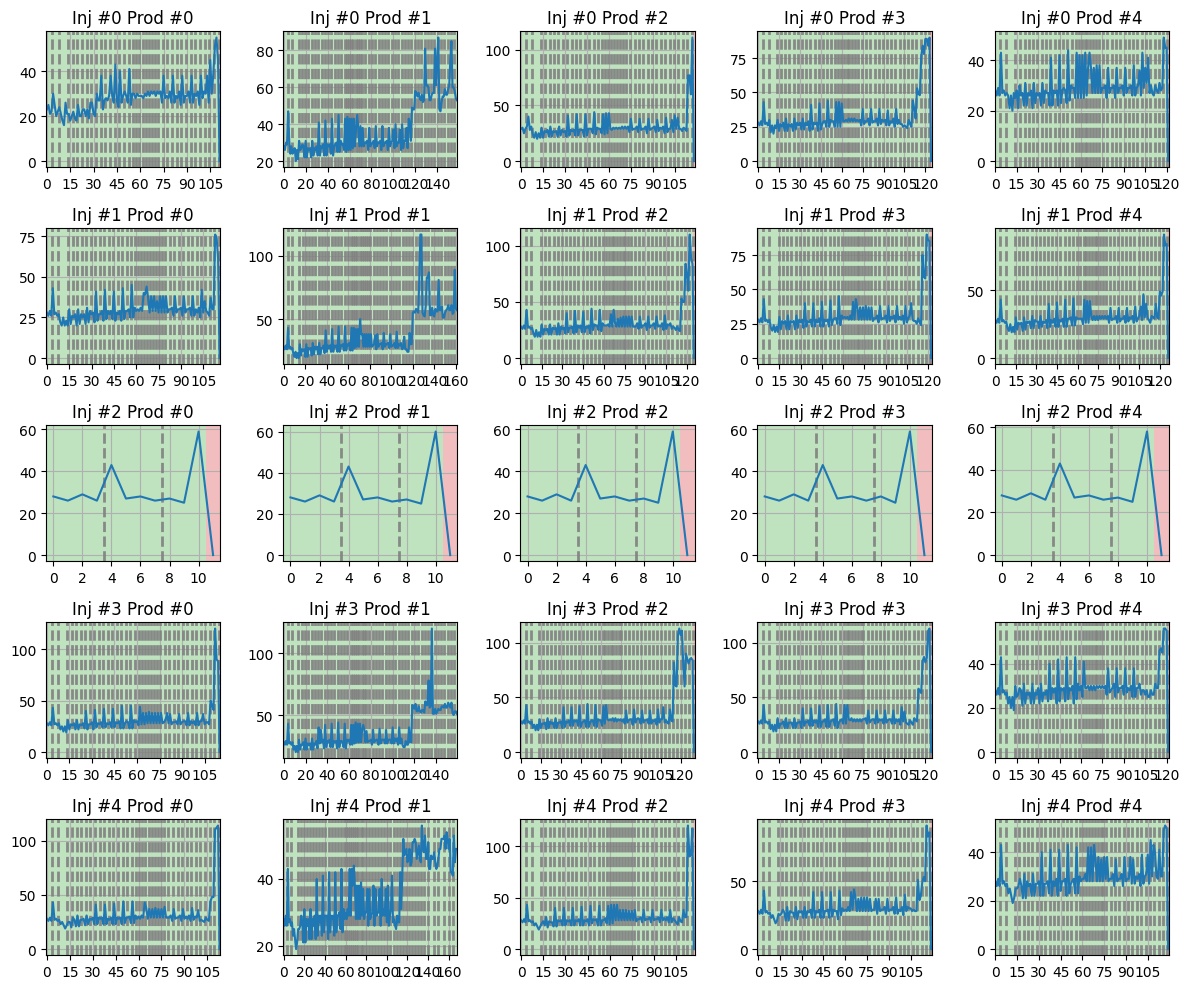

In [2]:
from itertools import count
from plot_utils import (
    color_converged_reason,
    color_time_steps,
    get_gmres_iterations,
    load_data,
    get_cfl,
    get_enthalpy_max,
    get_peclet_max,
    get_temp_max,
    get_temp_min,
    get_num_sticking_sliding_open,
)
from solver_selection_thm.thm_runscript import inlet_placements, outlet_placements
from solver_selection_thm.physics import simulation_name


data_simulations = []

counter = count()
for i, inlet_placement in enumerate(inlet_placements):
    data_row = []
    data_simulations.append(data_row)
    for j, outlet_placement in enumerate(outlet_placements):
        params["inlet_placement"] = inlet_placement
        params["outlet_placement"] = outlet_placement
        sim_name = f"{next(counter)}_{simulation_name(params)}"
        try:
            data = load_data(f"./stats/{sim_name}.json")
            data_row.append(data)
        except FileNotFoundError:
            data_row.append(None)


fig, axes = plt.subplots(
    nrows=len(inlet_placements), ncols=len(outlet_placements), figsize=(12, 10)
)
for i, data_row in enumerate(data_simulations):
    for j, data in enumerate(data_row):
        if data == None:
            continue
        ax = axes[i][j]
        plt.sca(ax)

        color_converged_reason(data)
        color_time_steps(data)
        # st, sl, op = get_num_sticking_sliding_open(data)

        ax.plot(get_gmres_iterations(data))
        # ax.plot(st)
        # ax.plot(sl)
        # ax.plot(op)
        # ax.set_yscale('log')
        print(inlet_placement, outlet_placement)
        ax.set_title(f"Inj #{i} Prod #{j}")

plt.tight_layout()

In [3]:
solver_space = SolverSpace(
    solver_space_scheme=make_solver_space_scheme_fthm(nd=3),
    solver_scheme_builders=KNOWN_SOLVER_COMPONENTS_THM,
)
num_solvers = solver_space.all_decisions_encoding.shape[0]
performance_predictor = PerformancePredictorPassiveAgressive(num_solvers=num_solvers)
solver_selector = SolverSelector(
    reward_estimator=RewardEstimator(),
    solver_space=solver_space,
    performance_predictor=performance_predictor,
)
print(solver_space.decision_tree)
print('\nNum solvers:', num_solvers)

block_type: LinearTransformedScheme
| elim_options (fork with 1 branches):
| | pc_type: hmg
| | | hmg_inner_pc_hypre_boomeramg_strong_threshold: Choices from 0.5 to 0.8, len = 4
| | | mg_levels_ksp_max_it: Choices from 1 to 8, len = 4
| | | mg_levels_ksp_type (fork with 2 branches):
| | | | chebyshev
| | | | richardson
| | | mg_levels_pc_type (fork with 1 branches):
| | | | ilu
| block_type (fork with 1 branches):
| | block_type: PetscFieldSplitScheme
| | | python_pc_hypre_boomeramg_strong_threshold: Choices from 0.5 to 0.5, len = 1

Num solvers: 32


In [4]:
solver_selector.history.load('./solver_selection_history.npy')
history = solver_selector.history
decision_id = np.array(history.decision_idx)
X, y = np.array(history.features), np.array(history.reward)

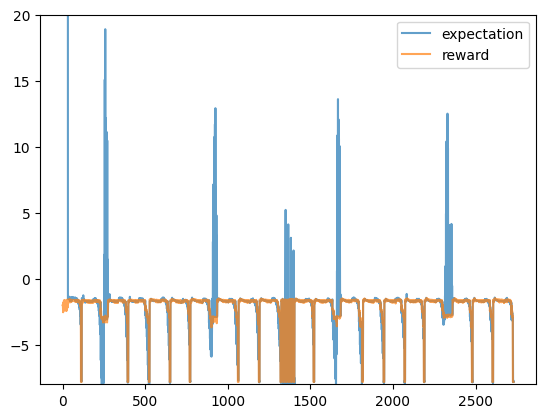

In [5]:
plt.plot(history.expectation, label="expectation", alpha=0.7)
plt.plot(history.reward, label="reward", alpha=0.7)
plt.ylim(top=20, bottom=-8)
plt.legend()

# In offline setting, how well does the data describe the target?
1. Estimating Mutual Information (MI)

<BarContainer object of 17 artists>

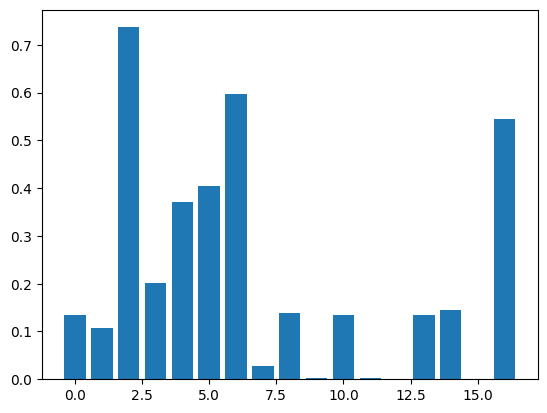

In [6]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

# compute MI
mi = mutual_info_regression(
    StandardScaler().fit_transform(X), y, n_neighbors=10, random_state=42
)
plt.bar(range(len(mi)), mi)

# mi[i] is the estimated MI between X[:, i] and y

In [72]:
from sklearn.linear_model import PassiveAggressiveRegressor, SGDRegressor
from sklearn.preprocessing import StandardScaler

# Only this model is used
def make_model():
    scaler = StandardScaler()
    # scaler = StandardScaler(with_mean=False, with_std=False)
    # regressor = PassiveAggressiveRegressor(random_state=42)
    regressor = SGDRegressor(
        penalty="l2",
        random_state=42,
        # learning_rate="pa1",  # better without
        # loss="epsilon_insensitive",
        epsilon=0.1,
    )
    # regressor = KNeighborsRegressor(n_neighbors=10)
    return scaler, regressor

2. Training offline model with cross-validation and comparing its

In [73]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_validate

offline_pipeline = make_pipeline(*make_model()) 
cv_results = cross_validate(offline_pipeline, X, y, cv=6, scoring="r2", return_train_score=True, return_estimator=True)

# Output
print("Train R² scores:", cv_results["train_score"])
print("Test R² scores:", cv_results["test_score"])
print("Mean Train R²:", np.mean(cv_results["train_score"]))
print("Mean Test R²:", np.mean(cv_results["test_score"]))

best_regressor_offline = cv_results['estimator'][np.argmax(cv_results['test_score'])]
best_regressor_offline

Train R² scores: [0.59750468 0.57989268 0.53037317 0.50222774 0.57913856 0.58337114]
Test R² scores: [0.25075219 0.45349303 0.66930942 0.7518371  0.46076532 0.43580084]
Mean Train R²: 0.562084661149964
Mean Test R²: 0.503659651680631


,steps,"[('standardscaler', ...), ('sgdregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15


3. We split data into offline and online. Online data is to be used for cross-validation split to train and test.

In [74]:
sep = num_solvers
Xoffline, yoffline = X[:sep], y[:sep]
Xonline, yonline = X[sep:], y[sep:]

3. Cross-validation R2 score of the online model

In [75]:
from sklearn.base import BaseEstimator, RegressorMixin
import math


class OnlineRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, Xoffline, yoffline):
        self.Xoffline = Xoffline
        self.yoffline = yoffline
        self.scaler, self.regressor = make_model()
        self.scaler.fit(Xoffline)
        self.regressor.fit(self.scaler.transform(Xoffline), yoffline)
        self.window_size = 1

    def fit(self, X, y):
        for i in range(math.ceil(X.shape[0] / self.window_size)):
            start = i * self.window_size
            end = start + self.window_size
            Xbatch, ybatch = X[start:end], y[start:end]
            self.scaler.partial_fit(Xbatch)
            self.regressor.partial_fit(self.scaler.transform(Xbatch), ybatch)

    def predict(self, X):
        return self.regressor.predict(self.scaler.transform(X))

    

online_regressor = OnlineRegressor(Xoffline, yoffline)
cv_results_online = cross_validate(online_regressor, Xonline, yonline, cv=6, scoring="r2", return_train_score=True, return_estimator=True)

# Output
print("Train R² scores:", cv_results_online["train_score"])
print("Test R² scores:", cv_results_online["test_score"])
print("Mean Train R²:", np.mean(cv_results_online["train_score"]))
print("Mean Test R²:", np.mean(cv_results_online["test_score"]))

best_regressor_online = cv_results_online['estimator'][np.argmax(cv_results_online['test_score'])]
best_regressor_online

Train R² scores: [0.55374134 0.54413247 0.48880649 0.51369998 0.55945032 0.53719911]
Test R² scores: [0.29169107 0.44307968 0.66833621 0.67298302 0.46430335 0.27095661]
Mean Train R²: 0.5328382839860191
Mean Test R²: 0.4685583237561697


,Xoffline,array([[ 3.93...0000000e+00]])
,yoffline,array([-1.995... -2.17313784])


4. Now we treat them as classifiers. Offline - ground truth. How often does Online make different decisions? How much does this cost to it?

In [76]:
from sklearn.neighbors import KNeighborsRegressor

def stack_features_solvers(features: np.ndarray, solvers: np.ndarray) -> np.ndarray:
    dim0 = solvers.shape[0]
    dim1 = features.shape[0]
    features = np.broadcast_to(features, (dim0, dim1))
    return np.concatenate([features, solvers], axis=1)


best_regressor_offline = KNeighborsRegressor(n_neighbors=20)
best_regressor_offline.fit(X, y)

all_solvers = solver_selector.solver_space.all_decisions_encoding
Xonline_features = Xonline[:, : -all_solvers.shape[1]]  # removing solvers encoding
Xonline_features.shape

scaler_online, regressor_online = make_model()
scaler_online.fit(Xoffline)
regressor_online.fit(scaler_online.transform(Xoffline), yoffline)

decisions_online = []
decisions_offline = []
reward_offline = []
reward_online = []
reward_feedback = []

for Xfeature in Xonline_features:
    x_to_predict = stack_features_solvers(Xfeature, all_solvers)

    # online
    predictions_online = regressor_online.predict(scaler_online.transform(x_to_predict))
    max_score_idx_online = np.argmax(predictions_online)
    max_score_online = predictions_online[max_score_idx_online]

    # offline
    predictions_offline = best_regressor_offline.predict(x_to_predict)
    max_score_idx_offline = np.argmax(predictions_offline)
    max_score_offline = predictions_offline[max_score_idx_offline]

    # feedback
    X_feedback = x_to_predict[max_score_idx_online].reshape(1, -1)
    y_feedback = predictions_offline[max_score_idx_online]
    scaler_online.partial_fit(X_feedback, [y_feedback])
    regressor_online.partial_fit(scaler_online.transform(X_feedback), [y_feedback])

    # saving stats
    decisions_offline.append(max_score_idx_offline)
    decisions_online.append(max_score_idx_online)
    reward_feedback.append(y_feedback)
    reward_offline.append(max_score_offline)
    reward_online.append(max_score_online)

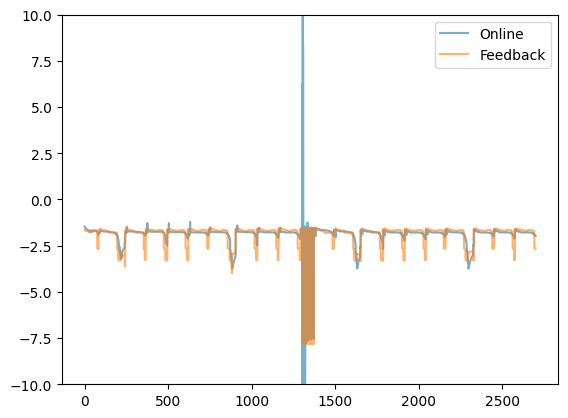

In [81]:
plt.plot(reward_online, label='Online', alpha=0.6)
plt.plot(reward_feedback, label='Feedback', alpha=0.6)
plt.ylim(-10, 10)
plt.legend()

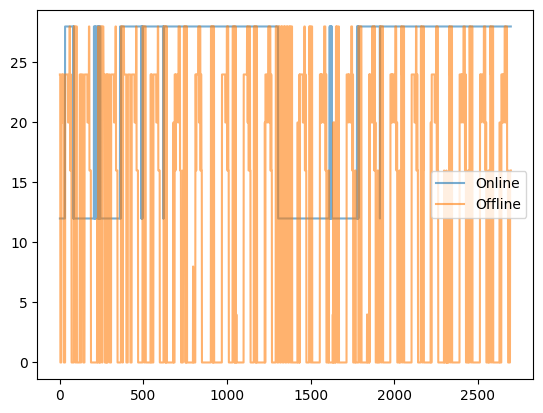

In [78]:
plt.plot(decisions_online, label='Online', alpha=0.6)
plt.plot(decisions_offline, label='Offline', alpha=0.6)
# plt.plot(history.decision_idx, label='Real', alpha=0.6)
plt.legend()

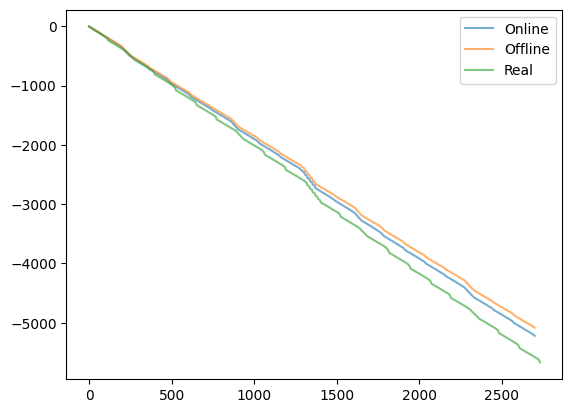

In [79]:
plt.plot(np.cumsum(reward_feedback), label='Online', alpha=0.6)
plt.plot(np.cumsum(reward_offline), label='Offline', alpha=0.6)
plt.plot(np.cumsum(history.reward), label='Real', alpha=0.6)
plt.legend()

# FOR TOMORROW
5. When does the online regressor select a solver from the same group as the offline regressor? Make classification metric, not for solver classes but for groups

6. Explain features

In [268]:
Xfeature

array([3.13008937e+02, 3.92997842e+02, 7.23350420e-04, 2.66054004e-03,
       1.49725027e-05, 6.68183475e-07, 8.47175432e-09, 4.70000000e-01,
       0.00000000e+00])

In [52]:
from sklearn.decomposition import IncrementalPCA
from sklearn.discriminant_analysis import StandardScaler
from sklearn.linear_model import PassiveAggressiveRegressor, SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

window_size = 1
# regressor = PassiveAggressiveRegressor(random_state=42)
poly_features = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
regressor = SGDRegressor(penalty=None, random_state=42, learning_rate='pa1', loss='epsilon_insensitive', epsilon=0.1)
transform_pipeline = make_pipeline(
    poly_features,
    StandardScaler(),
)
online_pipeline = make_pipeline(transform_pipeline, regressor)

online_pipeline.fit(Xoffline, yoffline)
ypred = []

for i in range(Xonline.shape[0] // window_size):
    start = sep + i * window_size
    end = start + window_size
    Xbatch, ybatch = X[start:end], y[start:end]
    ypred.extend(online_pipeline.predict(Xbatch))
    regressor.partial_fit(transform_pipeline.transform(Xbatch), ybatch)

abs(np.subtract(ypred, history.expectation[sep:])).max()

1.815436689867056e-12

In [ ]:
from sklearn.metrics import r2_score

r2_score(onli)

0.20128574332382243

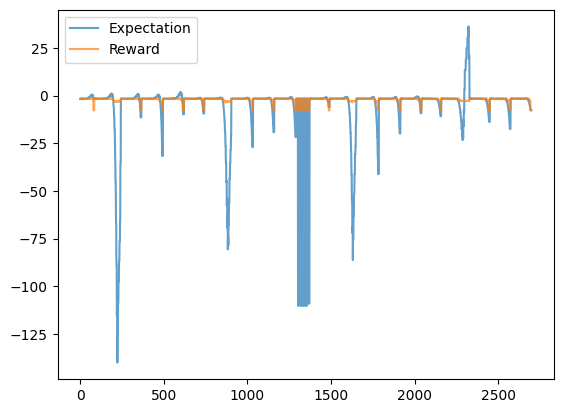

In [ ]:
ypred = online_pipeline.predict(Xonline)
plt.plot(ypred, label='Expectation', alpha=0.7)
# plt.plot(history.expectation[sep:], label='Real Expectation', alpha=0.9)
plt.plot(yonline, label='Reward', alpha=0.7)
plt.legend()